In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import rasterio
import os

In [13]:
def analyze_nodules(csv_path, nodule_density_kg_m3=2000, boem_factor_kg_m2=15.0):
    """
    Analyzes underwater nodule metrics from a CSV and outputs a single 
    size distribution plot with density estimates embedded as a text box
    and the total nodule count included in the legend.
    """
    
    # 1. Load Data & Clean Negative Polygon Areas
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['equivalent_diameter (meters)'])
    
    # Enforce absolute values to defend against negative geometries/transforms
    df['equivalent_diameter (meters)'] = df['equivalent_diameter (meters)'].abs()
    df['area (meters)'] = df['area (meters)'].abs()
    df['equivalent_diameter_mm'] = df['equivalent_diameter (meters)'] * 1000

    # 2. Extract Exact Image Areas and Resolutions via rasterio
    image_metadata = {}
    unique_image_paths = df['image_path'].unique()
    
    for path in unique_image_paths:
        try:
            with rasterio.open(path) as src:
                transform = src.transform
                pixel_width_m = abs(transform[0])
                pixel_height_m = abs(transform[4]) 
                
                total_area_m2 = (src.width * pixel_width_m) * (src.height * pixel_height_m)
                
                image_metadata[path] = {
                    'image_area_m2': total_area_m2,
                    'pixel_res_m': pixel_width_m
                }
        except Exception as e:
            print(f"Warning: Could not read image at {path}. Error: {e}")
            image_metadata[path] = {'image_area_m2': np.nan, 'pixel_res_m': np.nan}

    df['exact_pixel_res_m'] = df['image_path'].map(lambda x: image_metadata[x]['pixel_res_m'])
    df['image_area_m2'] = df['image_path'].map(lambda x: image_metadata[x]['image_area_m2'])
    df = df.dropna(subset=['image_area_m2'])

    # 3. Statistics & Uncertainty (in mm)
    diameters_mm = df['equivalent_diameter_mm']
    mean_d_mm = diameters_mm.mean()
    median_d_mm = diameters_mm.median()
    mode_d_mm = stats.mode(np.round(diameters_mm), keepdims=True)[0][0]
    mean_uncertainty_mm = df['exact_pixel_res_m'].mean() * 1000

    # 4. Mineral Density Calculations (in meters)
    df['volume_spherical_m3'] = (4/3) * np.pi * (df['equivalent_diameter (meters)'] / 2)**3
    df['mass_spherical_kg'] = df['volume_spherical_m3'] * nodule_density_kg_m3
    
    image_stats = df.groupby('image_name').agg({
        'area (meters)': 'sum',
        'mass_spherical_kg': 'sum',
        'image_area_m2': 'first'
    }).reset_index()

    # Calculate Overall Survey Aggregates for the Text Box
    total_survey_area = image_stats['image_area_m2'].sum()
    total_nodule_area = image_stats['area (meters)'].sum()
    total_spherical_mass = image_stats['mass_spherical_kg'].sum()
    
    overall_percent_cover = (total_nodule_area / total_survey_area) * 100
    overall_density_boem = (overall_percent_cover / 100.0) * boem_factor_kg_m2
    overall_density_spherical = total_spherical_mass / total_survey_area

    # ================= PLOTTING =================
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot Size Distribution
    sns.histplot(diameters_mm, bins=30, kde=True, color="skyblue", ax=ax)
    
    # Add Stat Lines
    ax.axvline(mean_d_mm, color='red', linestyle='--', label=f'Mean: {mean_d_mm:.1f} mm')
    ax.axvline(median_d_mm, color='green', linestyle='-', label=f'Median: {median_d_mm:.1f} mm')
    ax.axvline(mode_d_mm, color='purple', linestyle=':', label=f'Mode: {mode_d_mm:.1f} mm')
    
    # Add Uncertainty Shading
    ax.axvspan(mean_d_mm - mean_uncertainty_mm, mean_d_mm + mean_uncertainty_mm, 
               color='red', alpha=0.15, label=f'Pixel Uncertainty (±{mean_uncertainty_mm:.1f} mm)')
    
    # Add Total Count to Legend using a blank plot
    ax.plot([], [], ' ', label=f'Total Count: {len(df)}')
    
    # Format Labels & Legend
    ax.set_title('Nodule Size Distribution & Density Estimates', fontsize=14, pad=15)
    ax.set_xlabel('Equivalent Diameter (mm)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(loc='upper left') 

    # Create the Summary Text Box
    textstr = '\n'.join((
        r'$\bf{Overall\ Survey\ Estimates}$',
        f'Images Analyzed: {len(image_stats)}',
        f'Total Area: {total_survey_area:.2f} m²',
        f'Avg Cover: {overall_percent_cover:.1f}%',
        f'BOEM Density: {overall_density_boem:.2f} kg/m²',
        f'Spherical Density: {overall_density_spherical:.2f} kg/m²'
    ))

    # Place text box in the upper right
    props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.9)
    ax.text(0.96, 0.96, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.savefig('nodule_analysis_summary.png', dpi=300)
    plt.show()

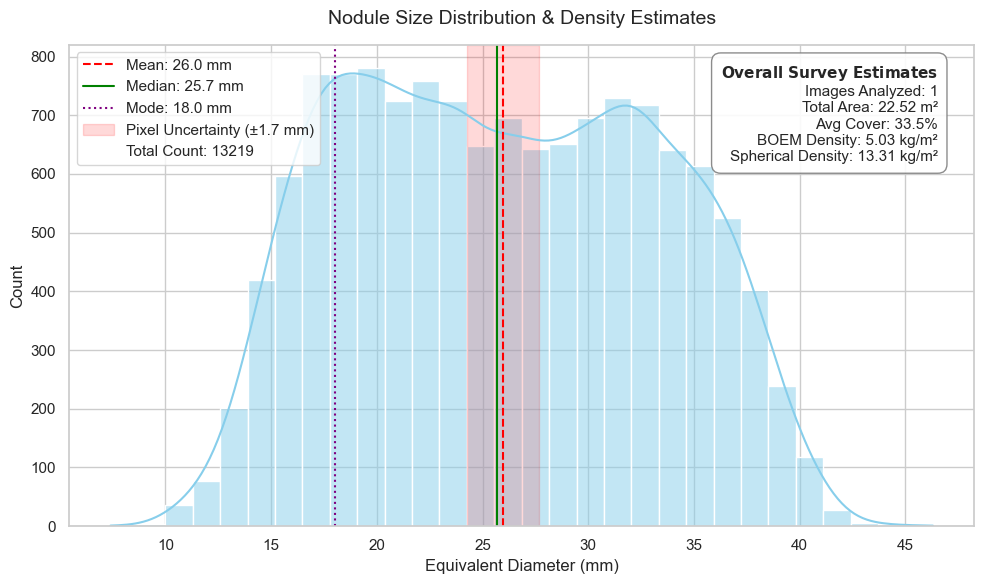

In [14]:
analyze_nodules("C:\\Users\\jordan\\Documents\\GitHub\\CoralNet-Toolbox\\data\\nodules\\nv5\\document\\spatial_metrics\\spatial_metrics.csv")